In [2]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Install ARFF file reader
!pip install liac-arff

# Import necessary libraries
import pandas as pd
import numpy as np
import arff
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11716 sha256=4bc7a07f1ad0eba59446fd9fc246003fc5b68e36ebe037b5b92967a5e0cf207c
  Stored in directory: /root/.cache/pip/wheels/00/23/31/5e562fce1f95aabe57f2a7320d07433ba1cd152bcde2f6a002
Successfully built liac-arff


In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

# Get the filename
file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

file_path = file_name  # Set the file path



Saving Autism-Child-Data.arff to Autism-Child-Data (1).arff
Uploaded file: Autism-Child-Data (1).arff


In [ ]:
# Read ARFF file
with open(file_name, "r") as f:
    dataset = arff.load(f)

# Convert to Pandas DataFrame
df = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])

# Display first few rows
df.head()


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,None,no,no,Jordan,yes,5.0,4-11 years,None,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,None,yes,no,Jordan,no,4.0,4-11 years,None,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10.0,4-11 years,Parent,YES


In [ ]:
# Check missing values
print(df.isnull().sum())

# Drop or fill missing values if needed
df = df.dropna()  # If necessary, use df.fillna(value)


A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 4
gender              0
ethnicity          43
jundice             0
austim              0
contry_of_res       0
used_app_before     0
result              0
age_desc            0
relation           43
Class/ASD           0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
label_encoders = {}

for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  # Store encoders for future use

# Display updated dataset
df.head()


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,1,5,0,0,23,0,5.0,0,1,0
1,1,1,0,0,1,1,0,1,0,0,...,1,4,0,0,23,0,5.0,0,1,0
4,1,1,1,1,1,1,1,1,1,1,...,1,5,1,0,45,0,10.0,0,1,1
6,1,0,1,1,1,1,0,1,0,1,...,1,9,0,0,44,0,7.0,0,1,1
7,1,1,1,1,1,1,1,1,0,0,...,0,4,0,0,5,0,8.0,0,1,1


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming the last column is the target variable (Autism diagnosis)
X = df.iloc[:, :-1]  # Features
y = df.iloc[:, -1]   # Target

# Split dataset into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_


Model Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        20

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



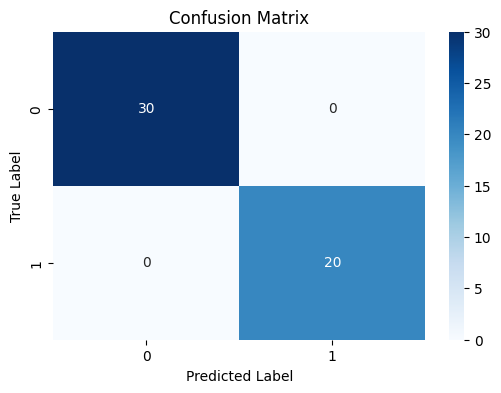

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Average cross-validation accuracy
print(f"Cross-Validation Accuracy: {cv_scores.mean():.2f}")
print(f"Cross-Validation Scores: {cv_scores}")


Cross-Validation Accuracy: 1.00
Cross-Validation Scores: [1. 1. 1. 1. 1.]


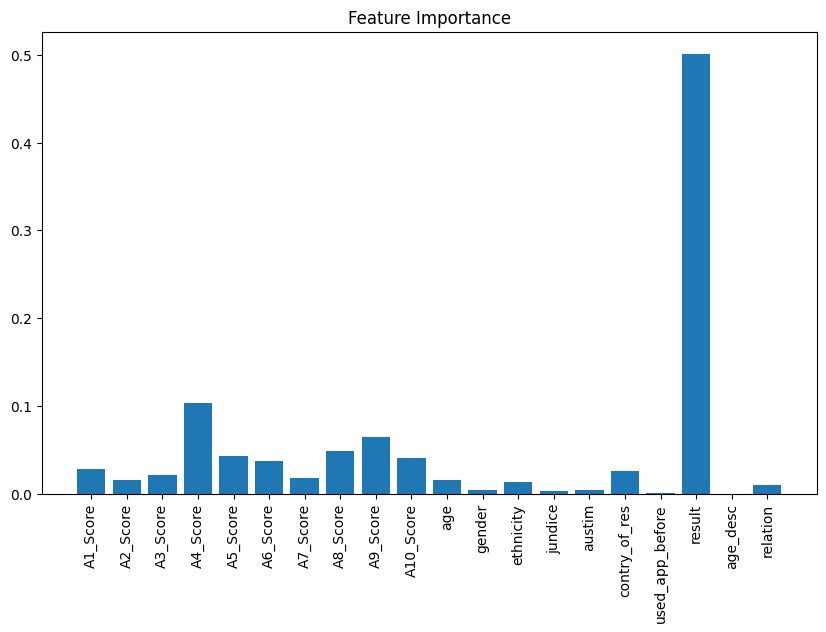

In [ ]:
# Feature Importance for Random Forest
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
feature_importances = model.feature_importances_

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(feature_importances)), feature_importances)
plt.xticks(np.arange(len(feature_importances)), X.columns, rotation=90)
plt.title("Feature Importance")
plt.show()


In [ ]:
# Training Accuracy
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")

# Testing Accuracy
test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print(f"Testing Accuracy: {test_accuracy:.2f}")


Training Accuracy: 1.00
Testing Accuracy: 1.00


In [ ]:
import joblib
import os

# Specify the directory to save files
save_directory = "C:/Users/ragug/OneDrive/Desktop"  # Change to your desired folder

# Ensure the directory exists
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

try:
    # Save the model
    joblib.dump(model, os.path.join(save_directory, "autism_rf_model.pkl"))

    # Save the scaler
    joblib.dump(scaler, os.path.join(save_directory, "scaler.pkl"))

    print(f"Model and scaler saved to {save_directory}")
except Exception as e:
    print(f"Error occurred while saving files: {e}")



Model and scaler saved to C:/Users/ragug/OneDrive/Desktop
